# <center>**Лабораторная работа №13** </center>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import log_loss

### **1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма).**

В первой колонке файла с данными записано, была или нет реакция. Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку на обучающую и тестовую, используя функцию train_test_split с параметрами test_size = 0.8 и random_state = 241.

In [4]:
data = pd.read_csv('gbm-data.csv')
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, random_state=241)

### **2. Обучите GradientBoostingClassifier с параметрами n_estimators=250, verbose=True, random_state=241 и для каждого значения learning_rate из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:**

Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой итерации.

Преобразуйте полученное предсказание по формуле 1/(1+e^(-y_pred)), где y_pred — предсказанное значение.

Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на котором оно достигается.

Размер обучающей выборки: (750, 1776)
Размер тестовой выборки: (3001, 1776)

Обучение с learning_rate = 1
      Iter       Train Loss   Remaining Time 
         1           1.0190           11.12s
         2           0.9192           11.13s
         3           0.8272           11.41s
         4           0.7834           11.07s
         5           0.7109           11.42s
         6           0.6368           11.12s
         7           0.5797           11.32s
         8           0.5610           11.41s
         9           0.5185           11.39s
        10           0.4984           11.44s
        20           0.1999           11.61s
        30           0.1313           11.32s
        40           0.0790           11.19s
        50           0.0511           10.55s
        60           0.0352           10.03s
        70           0.0245            9.48s
        80           0.0162            8.97s
        90           0.0114            8.41s
       100           0.0077           

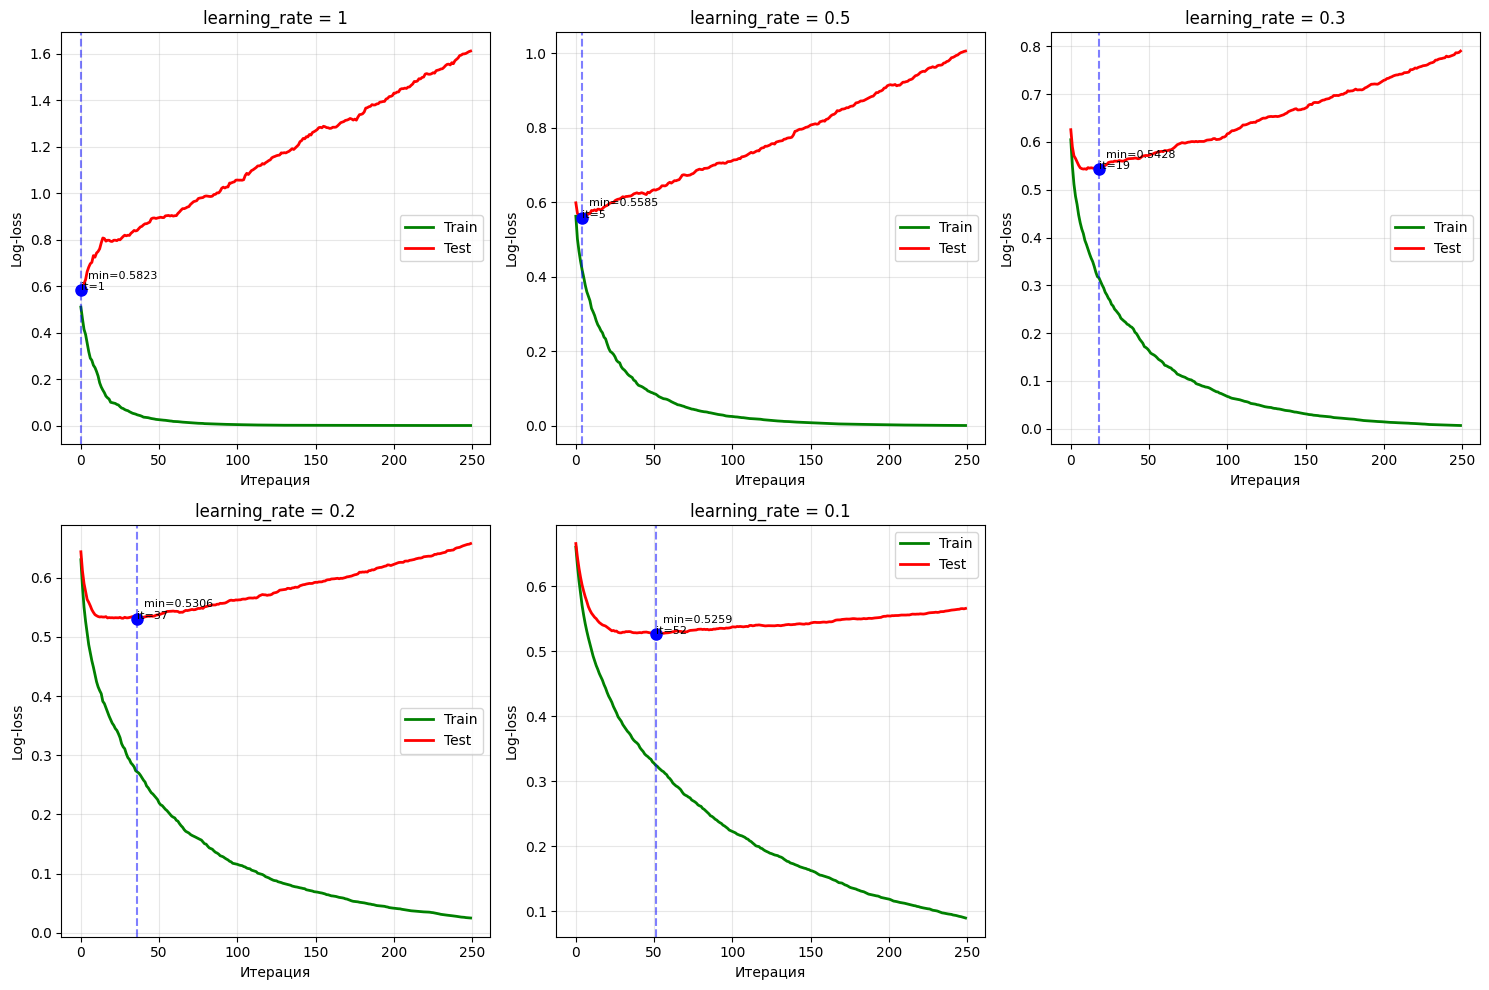

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, random_state=241
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


n_estimators = 250
random_state = 241
learning_rates = [1, 0.5, 0.3, 0.2, 0.1]


results = {}

for lr in learning_rates:
    print(f"\n{'='*60}")
    print(f"Обучение с learning_rate = {lr}")
    print('='*60)
    
    
    gbc = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=lr,
        random_state=random_state,
        verbose=True
    )
    gbc.fit(X_train, y_train)
    
    
    staged_train_pred = gbc.staged_decision_function(X_train)
    staged_test_pred = gbc.staged_decision_function(X_test)
    
    
    train_loss = []
    test_loss = []
    
    iteration = 0
    for train_pred, test_pred in zip(staged_train_pred, staged_test_pred):
    
        train_proba = 1 / (1 + np.exp(-train_pred))
        test_proba = 1 / (1 + np.exp(-test_pred))
        
        train_loss.append(log_loss(y_train, train_proba))
        test_loss.append(log_loss(y_test, test_proba))
        iteration += 1
        

        if iteration % 50 == 0:
            print(f"  Итерация {iteration}: train_loss = {train_loss[-1]:.6f}, test_loss = {test_loss[-1]:.6f}")
    

    min_test_loss = min(test_loss)
    min_iter = test_loss.index(min_test_loss) + 1  # +1 т.к. итерации с 1
    
    results[lr] = {
        'train_loss': train_loss,
        'test_loss': test_loss,
        'min_test_loss': min_test_loss,
        'min_iter': min_iter
    }
    
    print(f"\nРезультаты для learning_rate = {lr}:")
    print(f"  Минимальный log-loss на тесте: {min_test_loss:.6f}")
    print(f"  Номер итерации: {min_iter}")


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, lr in enumerate(learning_rates):
    ax = axes[i]
    
    train_loss = results[lr]['train_loss']
    test_loss = results[lr]['test_loss']
    min_iter = results[lr]['min_iter']
    min_test = results[lr]['min_test_loss']
    
    ax.plot(train_loss, 'g-', linewidth=2, label='Train')
    ax.plot(test_loss, 'r-', linewidth=2, label='Test')
    ax.set_title(f'learning_rate = {lr}')
    ax.set_xlabel('Итерация')
    ax.set_ylabel('Log-loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    

    ax.axvline(x=min_iter-1, color='blue', linestyle='--', alpha=0.5)
    ax.plot(min_iter-1, min_test, 'bo', markersize=8)
    ax.text(min_iter-1, min_test, f'  min={min_test:.4f}\nit={min_iter}', fontsize=8)


if len(learning_rates) < 6:
    axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('gbm_loss_curves.png', dpi=150)
plt.show()


### **3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или недообучение (underfitting)?**

В ответе укажите одно из слов overfitting либо underfitting.

При увеличении числа итераций test_loss сначала падает, затем начинает расти. Это классический признак overfitting

In [12]:
answer1 = "overfitting" 

print(f"Ответ: {answer1}")

with open('answer1.txt', 'w') as f:
    f.write(answer1)

Ответ: overfitting


### **4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при learning_rate = 0.2.**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    data.iloc[:, 1:].values, 
    data.iloc[:, 0].values, 
    test_size=0.8, 
    random_state=241
)

gbc = GradientBoostingClassifier(n_estimators=250, learning_rate=0.2, random_state=241)
gbc.fit(X_train, y_train)

test_loss = []
for pred in gbc.staged_decision_function(X_test):
    test_loss.append(log_loss(y_test, 1 / (1 + np.exp(-pred))))

min_loss = min(test_loss)
min_iter = test_loss.index(min_loss) + 1

answer = f"{min_loss:.2f} {min_iter}"
print(answer)

with open('answer2.txt', 'w') as f:
    f.write(answer)

0.53 37


### **5. На этих же данных обучите RandomForestClassifier с количеством деревьев, равным количеству итераций, на котором достигается наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию.**

Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью функции predict_proba. В данном случае брать сигмоиду от оценки вероятности класса не нужно.)"

In [14]:
gbc = GradientBoostingClassifier(n_estimators=250, learning_rate=0.2, random_state=241)
gbc.fit(X_train, y_train)

test_loss = []
for pred in gbc.staged_decision_function(X_test):
    test_loss.append(log_loss(y_test, 1 / (1 + np.exp(-pred))))

optimal_n = test_loss.index(min(test_loss)) + 1

rf = RandomForestClassifier(n_estimators=optimal_n, random_state=241)
rf.fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
rf_loss = log_loss(y_test, rf_pred)

answer = f"{rf_loss:.2f}"
print(answer)

with open('answer3.txt', 'w') as f:
    f.write(answer)

0.54
